In [ ]:
#DATA PREPROCESSING

import pandas as pd

# Load dataset
df = pd.read_csv("Churn_Modelling.csv")

print("Original Shape:", df.shape)

# Drop unnecessary columns
df.drop(["RowNumber", "CustomerId", "Surname"], axis=1, inplace=True)

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Remove missing values (if any)
df = df.dropna()

# One Hot Encoding for categorical columns
df = pd.get_dummies(df, columns=["Geography", "Gender"], drop_first=True)

print("\nAfter preprocessing shape:", df.shape)

# Separate features and target
X = df.drop("Exited", axis=1)
y = df["Exited"]

print("\nPreprocessing Done ✅")

df.to_csv("Churn_Preprocessed.csv", index=False)

print("Preprocessed file saved successfully ✅")

Original Shape: (10000, 14)

Missing Values:
 CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

After preprocessing shape: (10000, 12)

Preprocessing Done ✅
Preprocessed file saved successfully ✅


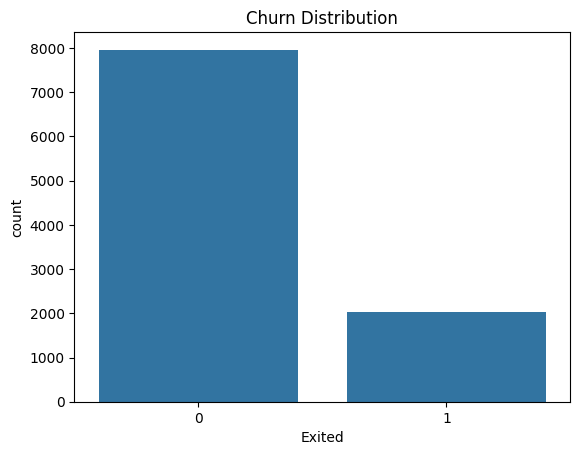

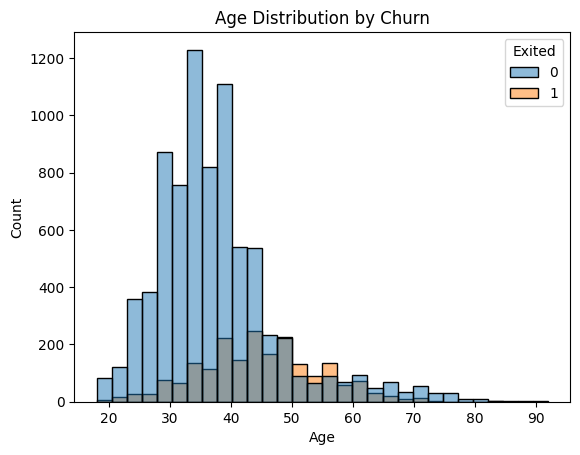

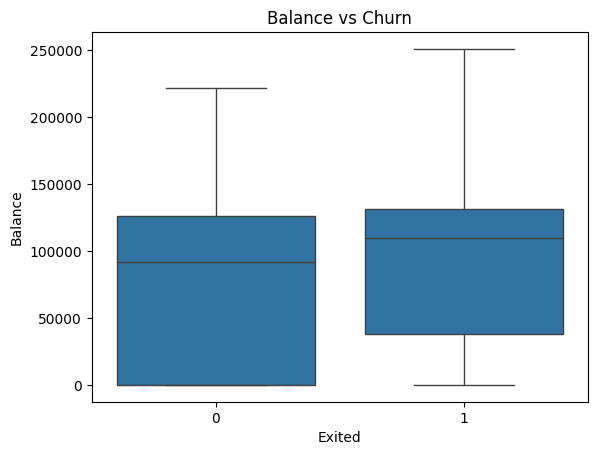

EDA Completed ✅


In [ ]:
# DATA VISUALIZATION

import matplotlib.pyplot as plt
import seaborn as sns

# Churn distribution
sns.countplot(x="Exited", data=df)
plt.title("Churn Distribution")
plt.show()

# Age vs Churn
sns.histplot(data=df, x="Age", hue="Exited", bins=30)
plt.title("Age Distribution by Churn")
plt.show()

# Balance vs Churn
sns.boxplot(x="Exited", y="Balance", data=df)
plt.title("Balance vs Churn")
plt.show()

print("EDA Completed ✅")

In [ ]:
# SPLITTING + SCALING

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split data
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data split and scaled ✅")

Data split and scaled ✅


In [ ]:
#  MODEL TRAINING

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

print("Model trained ✅")

Model trained ✅


In [ ]:
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(
    n_estimators=120,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

cv_scores = cross_val_score(rf, X, y, cv=5, scoring="accuracy", n_jobs=-1)
print("Cross-Validation Accuracy:", cv_scores.mean())

Cross-Validation Accuracy: 0.8398


In [ ]:
# BLOCK 4: MODEL EVALUATION

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_pred = rf.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, rf_pred))

print("\nClassification Report:\n", classification_report(y_test, rf_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_pred))


Accuracy: 0.8646666666666667

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92      1200
           1       0.75      0.48      0.59       300

    accuracy                           0.86      1500
   macro avg       0.82      0.72      0.75      1500
weighted avg       0.86      0.86      0.85      1500


Confusion Matrix:
 [[1153   47]
 [ 156  144]]


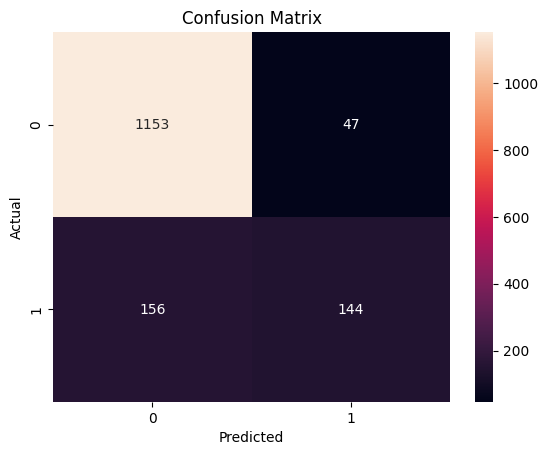

In [ ]:
# CONFUSION MATRIX

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

           Feature  Importance
1              Age    0.241742
7  EstimatedSalary    0.145268
3          Balance    0.142440
0      CreditScore    0.141835
4    NumOfProducts    0.128864


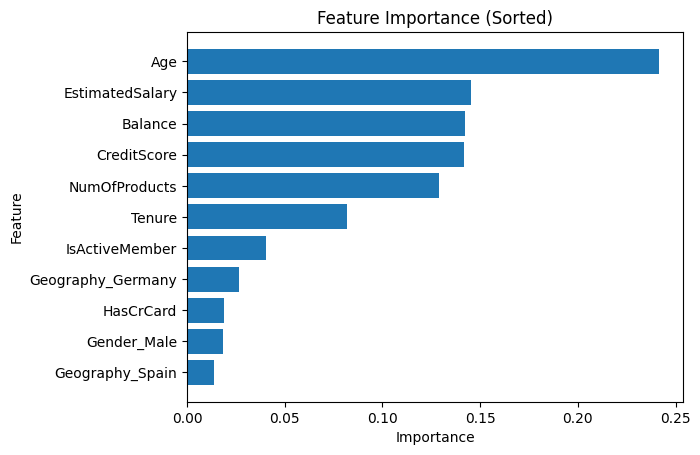

In [ ]:
# FEATURE IMPORTANCE

import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

# Sort values
importance_df = importance_df.sort_values(by="Importance", ascending=False)

print(importance_df.head())

plt.figure()
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Sorted)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
# CHURN PROBABILITY

probabilities = rf.predict_proba(X_test)

print("Sample Churn Probabilities:\n", probabilities[:5])

Sample Churn Probabilities:
 [[0.94 0.06]
 [0.17 0.83]
 [0.79 0.21]
 [0.94 0.06]
 [0.98 0.02]]


SAVING AND UI WORK

In [ ]:
import joblib

joblib.dump(rf, "churn_model.pkl")

['churn_model.pkl']

In [ ]:
# SAVE SCALER (VERY IMPORTANT)
joblib.dump(scaler, "scaler.pkl")

# SAVE FEATURE NAMES
joblib.dump(X.columns.tolist(), "features.pkl")

# SAVE MODEL (you already did this, but keep it here for clarity)
joblib.dump(rf, "churn_model.pkl")

print("✅ Model, Scaler, and Features saved successfully!")

✅ Model, Scaler, and Features saved successfully!
